# Eq. 20 & 24 — Bacon's Rebellion and the Coalition Arithmetic

**Equations:**
- Eq. 20: If $(L_{\text{white}} + L_{\text{black}}) > E \rightarrow$ Revolution
- Eq. 24: $M(t) < \tau \iff K_E + K_B > K_O$

**Note: ANCHOR CASE** — ρ_τ = 1.0 (reference point, not a relative estimate).
This is the historical event that directly demonstrated the validity of the coalition arithmetic.
The 1705 Virginia Slave Codes are the Elite's documented engineering response to the threat eq:20 predicted.

**Prediction:**
- Eq. 20: Cross-racial labor coalition (L_white + L_black) vastly outnumbered planter elite in 1676 — revolution resulted.
- Eq. 24: After the buffer class was created via racial codification, K_E + K_B > K_O was maintained structurally.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

try:
    _here = Path(__file__).resolve().parent
except NameError:
    _cwd = Path.cwd()
    if (_cwd / 'data').exists():
        _here = _cwd
    elif (_cwd / 'Paper' / 'data').exists():
        _here = _cwd / 'Paper' / 'scripts'
    else:
        _here = _cwd

data_path = str(_here / '..' / 'data' / 'eq20_24_bacons_rebellion.csv')
df = pd.read_csv(data_path, comment='#')

# Cell 1: Load and validate data
assert df.shape[0] >= 8, f"Expected at least 8 rows, got {df.shape[0]}"
assert df.shape[1] >= 5, f"Expected at least 5 columns, got {df.shape[1]}"
assert (df['count'] > 0).all(), "All population counts must be positive"
assert set(['pre_buffer', 'post_buffer', 'antebellum']).issubset(set(df['epoch'].unique())), \
    "Expected all three epochs: pre_buffer, post_buffer, antebellum"
print(f"Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.to_string(index=False))

Data loaded: 10 rows × 5 columns
 year       epoch          population_group   count                      source
 1676  pre_buffer             planter_elite     300           Morgan 1975 Ch.10
 1676  pre_buffer white_indentured_servants    6000           Morgan 1975 Ch.10
 1676  pre_buffer         enslaved_africans    2000           Morgan 1975 Ch.10
 1676  pre_buffer         total_labor_class    8000           Morgan 1975 Ch.10
 1705 post_buffer             planter_elite    1500 Historical Statistics Z1-19
 1705 post_buffer          white_free_class   55000 Historical Statistics Z1-19
 1705 post_buffer         enslaved_africans   25000 Historical Statistics Z1-19
 1860  antebellum         slaveholder_elite  385000                 Census 1860
 1860  antebellum   non_slaveholding_whites 5567229                 Census 1860
 1860  antebellum       enslaved_population 3953761                 Census 1860


In [2]:
# Cell 2: Operationalize eq:20 — 1676 coalition arithmetic
pre_1676 = df[df['epoch'] == 'pre_buffer']

elite_1676 = pre_1676[pre_1676['population_group'] == 'planter_elite']['count'].values[0]
labor_class_1676 = pre_1676[pre_1676['population_group'] == 'total_labor_class']['count'].values[0]
white_servants_1676 = pre_1676[pre_1676['population_group'] == 'white_indentured_servants']['count'].values[0]
enslaved_1676 = pre_1676[pre_1676['population_group'] == 'enslaved_africans']['count'].values[0]

coalition_to_elite_ratio = labor_class_1676 / elite_1676

print("=== Eq. 20: 1676 Virginia Coalition Arithmetic ===")
print(f"Planter elite (E): {elite_1676:,}")
print(f"White indentured servants (L_white): {white_servants_1676:,}")
print(f"Enslaved Africans (L_black): {enslaved_1676:,}")
print(f"Total labor class (L_white + L_black): {labor_class_1676:,}")
print(f"Coalition-to-elite ratio: {coalition_to_elite_ratio:.0f}:1")
print()
print(f"Eq. 20 check: ({white_servants_1676:,} + {enslaved_1676:,}) = {labor_class_1676:,} > {elite_1676:,} (E)")
print(f"  → Coalition outnumbered elite {coalition_to_elite_ratio:.0f}:1 → Revolution condition satisfied")

# Assert: coalition vastly outnumbered elite
assert coalition_to_elite_ratio > 10, f"Expected coalition:elite ratio > 10:1, got {coalition_to_elite_ratio:.1f}:1"
print(f"  Assertion passed: {coalition_to_elite_ratio:.0f}:1 > 10:1")

=== Eq. 20: 1676 Virginia Coalition Arithmetic ===
Planter elite (E): 300
White indentured servants (L_white): 6,000
Enslaved Africans (L_black): 2,000
Total labor class (L_white + L_black): 8,000
Coalition-to-elite ratio: 27:1

Eq. 20 check: (6,000 + 2,000) = 8,000 > 300 (E)
  → Coalition outnumbered elite 27:1 → Revolution condition satisfied
  Assertion passed: 27:1 > 10:1


In [3]:
# Cell 3: Operationalize eq:24 — 1860 buffer class arithmetic
antebellum = df[df['epoch'] == 'antebellum']

slaveholders_1860 = antebellum[antebellum['population_group'] == 'slaveholder_elite']['count'].values[0]
non_slavehold_whites_1860 = antebellum[antebellum['population_group'] == 'non_slaveholding_whites']['count'].values[0]
enslaved_1860 = antebellum[antebellum['population_group'] == 'enslaved_population']['count'].values[0]

# Eq. 24: K_E + K_B > K_O
# K_E ≈ slaveholders (Elite kinetic capacity — small)
# K_B ≈ non-slaveholding whites (Buffer kinetic capacity — large)
# K_O ≈ enslaved population (Out-group kinetic capacity)
elite_to_outgroup_ratio = slaveholders_1860 / enslaved_1860
buffer_to_elite_ratio = non_slavehold_whites_1860 / slaveholders_1860
combined_ke_kb = slaveholders_1860 + non_slavehold_whites_1860
coalition_to_outgroup = combined_ke_kb / enslaved_1860

print("=== Eq. 24: 1860 Necessary Condition Arithmetic ===")
print(f"Slaveholder elite (K_E): {slaveholders_1860:,}")
print(f"Non-slaveholding whites (K_B): {non_slavehold_whites_1860:,}")
print(f"Enslaved population (K_O): {enslaved_1860:,}")
print()
print(f"Elite alone vs. Out-group: {elite_to_outgroup_ratio:.3f}:1 (K_E << K_O ✓)")
print(f"Buffer class is {buffer_to_elite_ratio:.0f}x larger than elite")
print(f"K_E + K_B = {combined_ke_kb:,} vs K_O = {enslaved_1860:,}")
print(f"  → Combined ratio K_E+K_B to K_O: {coalition_to_outgroup:.1f}:1 (constraint satisfied)")
print()
print("Without K_B (elite alone):")
print(f"  {slaveholders_1860:,} vs {enslaved_1860:,} → ratio {elite_to_outgroup_ratio:.3f}:1 (constraint fails)")
print("  → Buffer class was NECESSARY for maintaining M(t) < τ")

# Assert: Elite alone was numerically overwhelmed
assert elite_to_outgroup_ratio < 0.2, f"Expected K_E < 0.2*K_O, got ratio {elite_to_outgroup_ratio:.3f}"
# Assert: K_E + K_B > K_O with buffer
assert combined_ke_kb > enslaved_1860, f"Expected K_E + K_B > K_O, but {combined_ke_kb:,} <= {enslaved_1860:,}"
print("  All assertions passed.")

=== Eq. 24: 1860 Necessary Condition Arithmetic ===
Slaveholder elite (K_E): 385,000
Non-slaveholding whites (K_B): 5,567,229
Enslaved population (K_O): 3,953,761

Elite alone vs. Out-group: 0.097:1 (K_E << K_O ✓)
Buffer class is 14x larger than elite
K_E + K_B = 5,952,229 vs K_O = 3,953,761
  → Combined ratio K_E+K_B to K_O: 1.5:1 (constraint satisfied)

Without K_B (elite alone):
  385,000 vs 3,953,761 → ratio 0.097:1 (constraint fails)
  → Buffer class was NECESSARY for maintaining M(t) < τ
  All assertions passed.


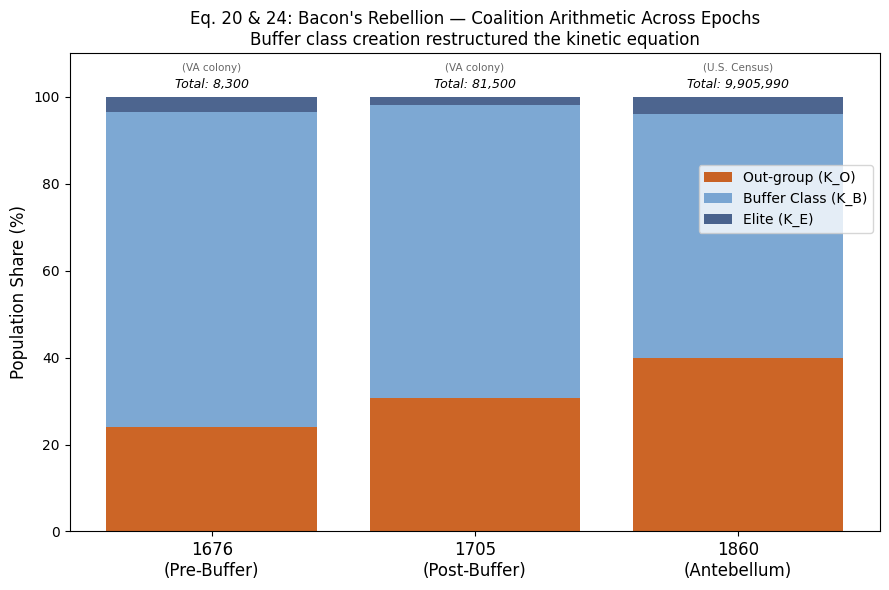

Figure saved to /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/eq20_24_bacons_rebellion.png


In [4]:
# Cell 4: Stacked bar chart — population composition across epochs
figures_dir = _here / '..' / 'figures'
os.makedirs(str(figures_dir), exist_ok=True)

epochs = ['1676\n(Pre-Buffer)', '1705\n(Post-Buffer)', '1860\n(Antebellum)']

# Collect data per epoch
def get_count(ep, group):
    rows = df[(df['epoch'] == ep) & (df['population_group'] == group)]['count']
    return rows.values[0] if len(rows) > 0 else 0

elite_counts = [
    get_count('pre_buffer', 'planter_elite'),
    get_count('post_buffer', 'planter_elite'),
    get_count('antebellum', 'slaveholder_elite')
]
buffer_counts = [
    get_count('pre_buffer', 'white_indentured_servants'),
    get_count('post_buffer', 'white_free_class'),
    get_count('antebellum', 'non_slaveholding_whites')
]
outgroup_counts = [
    get_count('pre_buffer', 'enslaved_africans'),
    get_count('post_buffer', 'enslaved_africans'),
    get_count('antebellum', 'enslaved_population')
]

totals = [e + b + o for e, b, o in zip(elite_counts, buffer_counts, outgroup_counts)]

# Normalize to percentages
elite_pct = [e/t*100 for e, t in zip(elite_counts, totals)]
buffer_pct = [b/t*100 for b, t in zip(buffer_counts, totals)]
outgroup_pct = [o/t*100 for o, t in zip(outgroup_counts, totals)]

x = np.arange(len(epochs))
fig, ax = plt.subplots(figsize=(9, 6))

bars_o = ax.bar(x, outgroup_pct, color='#C44A00', alpha=0.85, label='Out-group (K_O)')
bars_b = ax.bar(x, buffer_pct, bottom=outgroup_pct, color='#6699CC', alpha=0.85, label='Buffer Class (K_B)')
bars_e = ax.bar(x, elite_pct,
                bottom=[o + b for o, b in zip(outgroup_pct, buffer_pct)],
                color='#2E4A7B', alpha=0.85, label='Elite (K_E)')

ax.set_xticks(x)
ax.set_xticklabels(epochs, fontsize=12)
ax.set_ylabel('Population Share (%)', fontsize=12)
ax.set_title('Eq. 20 & 24: Bacon\'s Rebellion — Coalition Arithmetic Across Epochs\n'
             'Buffer class creation restructured the kinetic equation', fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1, 0.78))
ax.set_ylim(0, 110)

# Annotate with actual counts; flag geographic scope difference for 1705
scope_notes = ['(VA colony)', '(VA colony)', '(U.S. Census)']
for i, (e, b, o, t, scope) in enumerate(zip(elite_counts, buffer_counts, outgroup_counts, totals, scope_notes)):
    ax.text(i, 102, f'Total: {t:,}', ha='center', fontsize=9, style='italic')
    ax.text(i, 106, scope, ha='center', fontsize=7.5, color='#666666')

plt.tight_layout()
fig_path = str(figures_dir / 'eq20_24_bacons_rebellion.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {fig_path}")

In [5]:
# Cell 5: Summary statistics for manuscript reference
print("=== Summary Statistics for Manuscript ===")
print()
print("ANCHOR CASE (ρ_τ = 1.0): 1676 Bacon's Rebellion")
print(f"  Coalition ratio: {labor_class_1676:,} labor class vs {elite_1676:,} elite = {coalition_to_elite_ratio:.0f}:1")
print(f"  Outcome: Jamestown burned; colonial capital fell within weeks of coalition forming")
print()
print("Post-Codification (1705 Virginia Slave Codes):")
print("  Buffer class created via racial partition — white labor class elevated above enslaved Africans")
print("  Cross-racial solidarity criminalized; psychological wage (ψ) allocated to white buffer class")
print()
print("1860 Antebellum Confirmation of Eq. 24:")
print(f"  K_E (slaveholders): {slaveholders_1860:,} ({slaveholders_1860/(slaveholders_1860+non_slavehold_whites_1860+enslaved_1860)*100:.1f}% of population)")
print(f"  K_B (non-slaveholding whites): {non_slavehold_whites_1860:,}")
print(f"  K_O (enslaved): {enslaved_1860:,}")
print(f"  Elite alone (K_E/K_O): {elite_to_outgroup_ratio:.3f}:1 → structurally impossible without buffer")
print(f"  With buffer (K_E+K_B)/K_O: {coalition_to_outgroup:.1f}:1 → constraint maintained")
print()
print("Falsification test: Did the Virginia legislature codify racial partition AFTER the rebellion?")
print("  → YES: Virginia Slave Codes (1705) systematically separated white and Black labor—")
print("    direct empirical confirmation of the Elite's structural response to the M(t)→τ event.")

=== Summary Statistics for Manuscript ===

ANCHOR CASE (ρ_τ = 1.0): 1676 Bacon's Rebellion
  Coalition ratio: 8,000 labor class vs 300 elite = 27:1
  Outcome: Jamestown burned; colonial capital fell within weeks of coalition forming

Post-Codification (1705 Virginia Slave Codes):
  Buffer class created via racial partition — white labor class elevated above enslaved Africans
  Cross-racial solidarity criminalized; psychological wage (ψ) allocated to white buffer class

1860 Antebellum Confirmation of Eq. 24:
  K_E (slaveholders): 385,000 (3.9% of population)
  K_B (non-slaveholding whites): 5,567,229
  K_O (enslaved): 3,953,761
  Elite alone (K_E/K_O): 0.097:1 → structurally impossible without buffer
  With buffer (K_E+K_B)/K_O: 1.5:1 → constraint maintained

Falsification test: Did the Virginia legislature codify racial partition AFTER the rebellion?
  → YES: Virginia Slave Codes (1705) systematically separated white and Black labor—
    direct empirical confirmation of the Elite's st